In [5]:
import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

# --- Cargar los datos --
iris = load_iris()
X, y = iris.data, iris.target  # X = características (tamaño de pétalos/sépalos), y = tipo de flor

# --- Dividir en entrenamiento y prueba
# 70% para entrenar, 30% para probar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- Buscar los mejores parámetros con Grid Search ---
# Probamos diferentes combinaciones de parámetros para encontrar la mejor
param_grid = {
    'C': [0.1, 1, 10],              # Controla qué tan estricto es el modelo con los errores
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']      # Controla que tan lejos "mira" cada punto de datos
}

# GridSearchCV prueba todas las combinaciones con validación cruzada (5 partes)
grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)  # Entrenamos con todos los parámetros posibles

# El mejor modelo encontrado por la búsqueda
best_svm = grid.best_estimator_
print('Beste Params:', grid.best_params_)  # Muestra los mejores parámetros

# --- Evaluar el modelo ---
y_pred = best_svm.predict(X_test)  # El modelo
print('Accuracy:', accuracy_score(y_test, y_pred))  #
print(classification_report(y_test, y_pred))        # Reporte detallado por clase

# --- Reducir a 2 dimensiones para poder visualizar ---
# Los datos tienen 4 dimensiones, pero solo podemos dibujar 2
# PCA encuentra las 2 direcciones más importantes en los datos
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)  # Transformamos los datos de prueba a 2D

# --- Crear y guardar el gráfico
plt.figure(figsize=(8, 6))
# Dibujamos cada punto con un color según la clase predicha
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='viridis')
plt.xlabel('PCA 1')   # Primer componente principal
plt.ylabel('PCA 2')   # Segundo componente principal
plt.title('SVM-Entscheidungsstruktur (PCA-Projektion)')
plt.colorbar(scatter, ticks=[0, 1, 2], label='Klasse')  # Leyenda con los 3 tipos de flores
plt.tight_layout()
plt.savefig('svm_iris_pca.png', dpi=300)  # Guardamos el gráfico como imagen PNG
plt.close()


Beste Params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



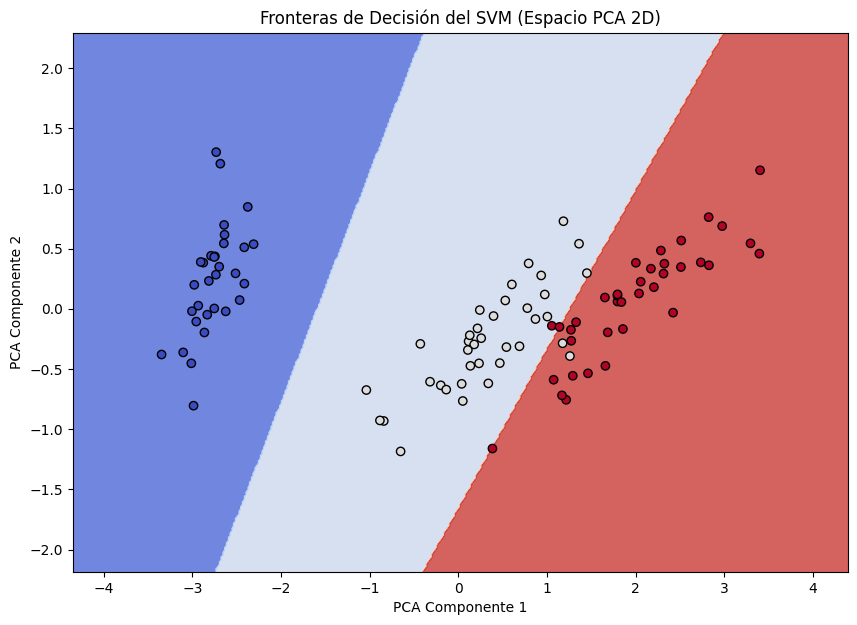

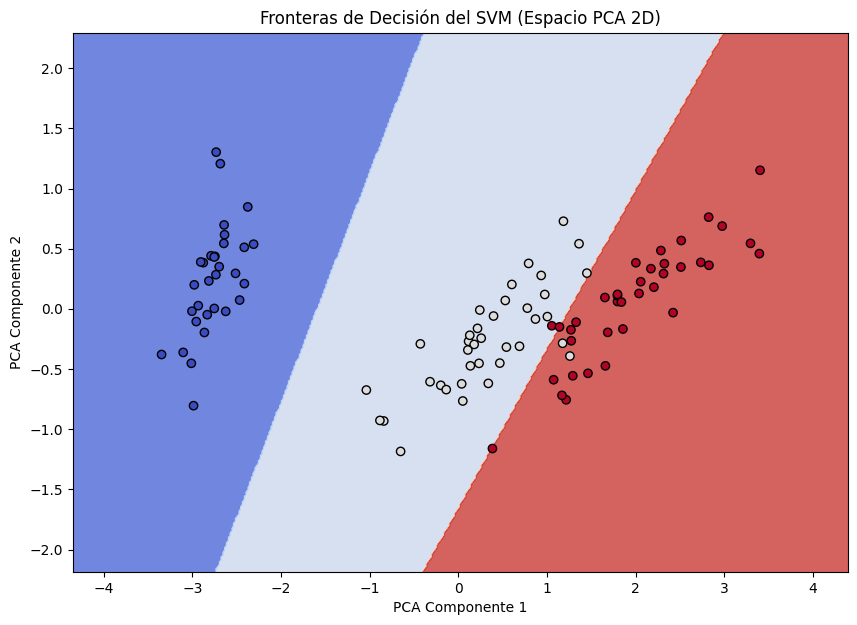

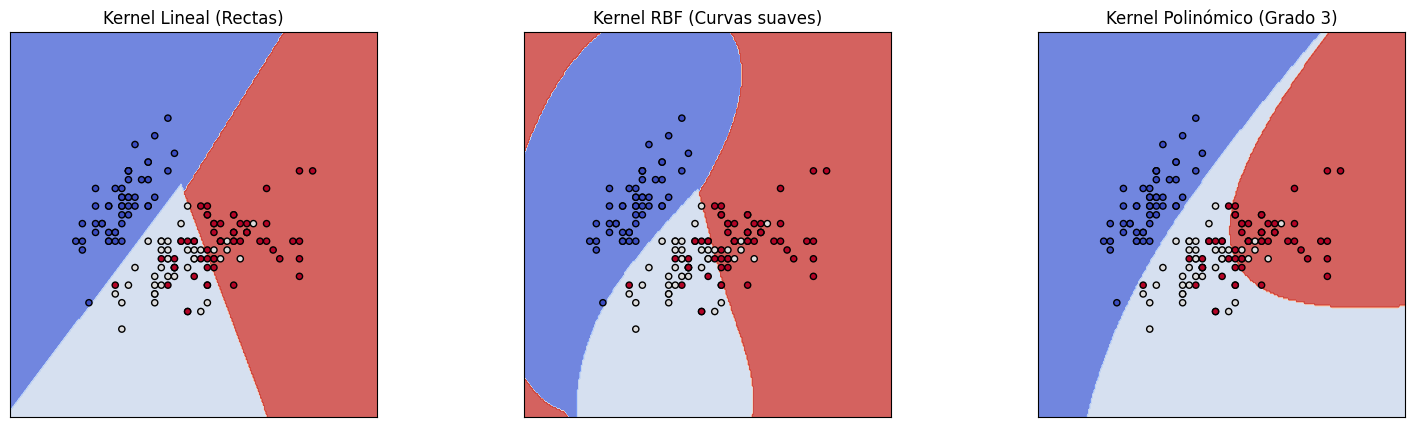

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm, datasets
from sklearn.decomposition import PCA

# Forzar el modo interactivo para que veas los gráficos aquí mismo
%matplotlib inline

# Cargamos datos y reducimos a 2D para visualización
iris = datasets.load_iris()
X = iris.data[:, :2] # Usamos solo las primeras 2 características para que sea más didáctico
y = iris.target

# Creamos diferentes modelos para comparar
C = 1.0  # Parámetro de regularización
models = (
    svm.SVC(kernel='linear', C=C),
    svm.SVC(kernel='rbf', gamma=0.7, C=C),
    svm.SVC(kernel='poly', degree=3, gamma='auto', C=C)
)
models = (clf.fit(X, y) for clf in models)

# Títulos para los gráficos
titles = ('Kernel Lineal (Rectas)',
          'Kernel RBF (Curvas suaves)',
          'Kernel Polinómico (Grado 3)')

# Configurar la malla para el dibujo
fig, sub = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

X0, X1 = X[:, 0], X[:, 1]
xx, yy = np.meshgrid(np.arange(X0.min()-1, X0.max()+1, 0.02),
                     np.arange(X1.min()-1, X1.max()+1, 0.02))

for clf, title, ax in zip(models, titles, sub.flatten()):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)

plt.show()

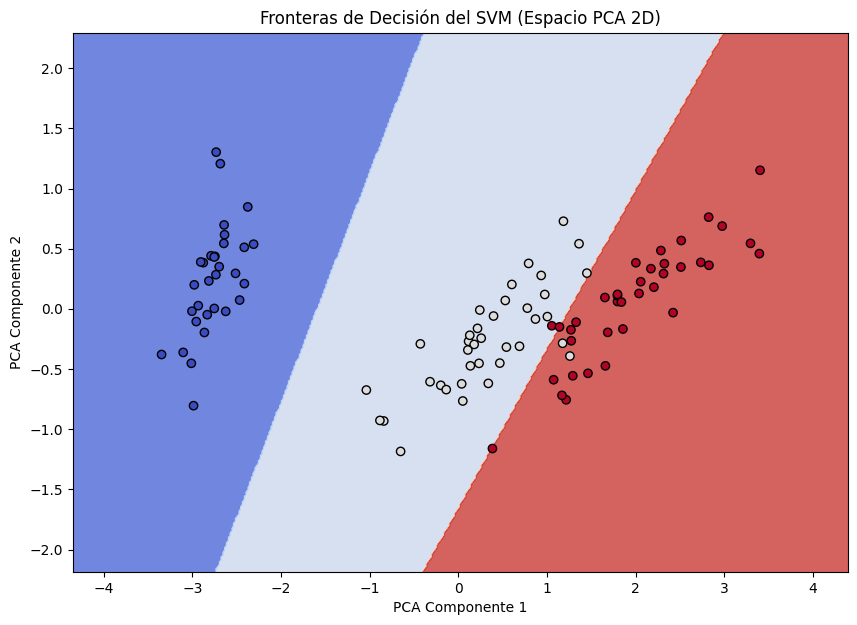

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Para visualizar la frontera, re-entrenamos el mejor modelo solo con las 2 componentes de PCA
pca_viz = PCA(n_components=2)
X_train_pca = pca_viz.fit_transform(X_train)

# Entrenamos con los mejores parámetros encontrados
svm_viz = SVC(**grid.best_params_)
svm_viz.fit(X_train_pca, y_train)

# Crear una malla (grid) para dibujar las regiones
h = .02  # tamaño del paso en la malla
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predecir sobre la malla
Z = svm_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Dibujar
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# Dibujar los puntos de entrenamiento encima
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train,
                      cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('PCA Componente 1')
plt.ylabel('PCA Componente 2')
plt.title('Fronteras de Decisión del SVM (Espacio PCA 2D)')
plt.show()